# Pipeline to

*   extract metadiscourse and style features for English Reddit posts and Chinese posts
*   Normalize metadiscourse features by post length
*   measure correlations between features










## Import packages

In [1]:
%%capture
# old one - openai==1.55.3
!pip install openai==2.0.0 httpx==0.27.2 --force-reinstall --quiet

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import sys
from google.colab import drive
import re
import json
import numpy as np
import nltk

In [3]:
import openai
from openai._client import OpenAI

In [4]:
#to access openai api keys
!pip install --quiet python-dotenv

In [5]:
## LLM API Calls - key
import dotenv

KEY_FILE_LOCATION = '/content/drive/MyDrive/API Keys/WWBP_OpenAIKey.env'
dotenv.load_dotenv(KEY_FILE_LOCATION)

True

In [6]:
# always clear this output before moving to next cell.
#!echo $OPENAI_API_KEY

In [7]:
openai.api_key = os.environ["OPENAI_API_KEY"]

## LLM Prompts to Label the Dataset In Terms of High- vs Low Context

In [ ]:
def label_contextLevel_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates how high- versus low-context various two to three sentence-long utterances are. Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. Return the output in float format."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate two to three sentence long utterances of various topics based on how high-context versus low-context they are.",
       "description": "For each utterance, answer this question: Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. /
       ALWAYS FOLLOW THE RATING SCALE OF 1 (very low-context) TO 5 (very high-context). DO NOT EXPLAIN YOUR ANSWERS",
      }}
  }},
  "annotation_format": "Return the score as either 1, 2, 3, 4, or 5, in float format.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "1"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

## LLM prompts to extract metadiscourse and style features

*   Metadiscourse features - Interactive and Interaction
*   There are two prompts below for metadiscourse features - one for English and one for Chinese.
* Style features for english



## English prompts

In [ ]:
## Run 2 - metadiscourse feature labeling.
def extract_metadiscourseFeatures_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in two to three sentence-long utterances. You return the annotated string in JSON format after, with the format as {'annotated_text' : the annotated output }."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in two to three sentence-long utterances are.",
       "description": "Identify and label metadiscourse markers in the given text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>. DO NOT INCLUDE ANY MARKERS OUTSIDE OF THE ONES LISTED BELOW. IF THE MARKER HAS UNDERSCORES, LABEL THEM WITH UNDERSCORES, NOT DASHES, FOR EXAMPLE: IF YOU SEE A SELF-MENTION, LABEL AS word<self_mentions>. DO NOT EXPLAIN YOUR ANSWERS",
  "categories": {{
    "interactive": {{
      "": {{
        "definition": "Words that express semantic relation between main clauses.",
        "examples": ["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"]
      }},
      "frame_markers": {{
        "definition": "Words that refer to discourse acts, sequences, or text stages.",
        "examples": ["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"]
      }},
      "endophoric_markers": {{
        "definition": "Words that refer to information from other parts of the text.",
        "examples": ["what I mentioned before", "the above", "above", "below", "first"]
      }},
      "evidentials": {{
        "definition": "Words that refer to a source of information from other texts.",
        "examples": ["as xxx once said", "according to xxx"]
      }},
      "code_glosses": {{
        "definition": "Words that help readers grasp meanings of ideational material.",
        "examples": ["such as", "for example", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "Words that withhold the writer's full commitment to a proposition.",
        "examples": ["might", "could", "I'm not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"]
      }},
      "boosters": {{
        "definition": "Words that emphasize force or the writer's certainty in a proposition.",
        "examples": ["definitely", "certainly", "really", "in fact", "exclamation marks (!)", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"]
      }},
      "attitude_markers": {{
        "definition": "Words that express the writer's attitude to a proposition.",
        "examples": ["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"]
      }},
      "engagement_markers": {{
        "definition": "Words that explicitly refer to or build a relationship with the reader.",
        "examples": ["consider this", "you can see that", "have to", "question marks (?)", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"]
      }},
      "self_mentions": {{
        "definition": "Words that indicate explicit reference to the author(s).",
        "examples": ["I", "we", "our", "me", "us", "my"]
      }}
    }},
    "other": {{
      "deontic_modal_words": {{
        "definition": "Words or word phrases that express concepts of obligation, permission, and prohibition, often in the context of what a person or agent is required, allowed, or forbidden to do.",
        "examples": ["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to"]
      }},
      "adverbs_of_degree": {{
        "definition": "Words that indicate the intensity, extent, or level of an action, adjective, or another adverb",
        "examples": ["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too"]
      }},
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "slang_and_colloquialisms": {{
        "definition": "Words or phrases commonly used in natural, highly informal, spoken conversations rather than in formal or literary writing, including ones popular in specific social groups.",
        "examples": ["going postal", "bogus", "adulting", "y'all", "what's up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin". "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow-up", "GOAT", "let them cook", "irl", "mood"]
      }},
      "positive_connotations": {{
        "definition": "Words with emotional or cultural associations that goes beyond their literal meanings, with positive connotations evoke pleasant or favorable feelings and associations.",
        "examples": ["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent"]
      }},
      "negative_connotations": {{
        "definition": "Words with unpleasant or unfavorable emotional associations or implied meanings, beyond their literal definitiona.",
        "examples": ["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }},
      "chronological_markers": {{
        "definition": "Words or phrases that establish a chronological ordering of events within the text."
        "examples": ["first", "next", "second", "afterwards", "later", "finally", "then", "before", "during", "after", "today", "tomorrow"]
      }},
      "causal_markers": {{
        "definition": "Words or phrases that establish a cause-and-effect relationship between events within the text."
        "examples": ["since", "because", "thus", "so", "as", "therefore", "due to", "as a result"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "Some guy tried to do the same thing with me<self-mentions> once!<boosters> He faked cancer for about a month, then<transitions> one day, he “had a heart attack,”<boosters> and told me<self-mentions> the hospital he was admitted into. I<self-mentions> called the hospital, and they had no record of him there. So I<self-mentions> aggressively confronted the guy, he admitted he was lying about everything, and I<self-mentions> told him he needed professional mental help. People who are THIS<boosters> crazy are scary… they don’t know what’s right vs wrong."
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  # gpt-5 only params: reasoning_effort
  # reasoning_effort="low",
  verbosity="low",
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0,
  response_format={"type": "json_object"}
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

In [ ]:
## Run 2 - style feature analysis
def extract_styleFeatures_english(post, temp):
    response = openai.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "system",
                "content": "You are an AI assistant trained to evaluate and annotate utterances in social media posts based on various criteria. Rate each question on a scale from 1 (not at all) to 7 (very much), unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Annotate social media post utterances (defined as: 2-3 sentence long segments) based on multiple linguistic and psychological dimensions.",
                    "description": "Rate each of the following questions on a scale of 1 (not at all) to 7 (very much). Select temporal orientation as past, present, or future. If multiple orientations apply, return all that apply.\
                    ALWAYS FOLLOW THE RATING SCALE OF 1 (not at all) TO 7 (very much) EXCEPT FOR TEMPORAL ORIENTATION. GIVE A RATING FOR EVERY DIMENSION LISTED BELOW, AND ONLY THOSE. DO NOT EXPLAIN YOUR ANSWERS.\
                    ",
                    "criteria": {{
                        "informativeness": "How much does this utterance provide information or solutions?",
                        "constructive_feedback": "How much does this utterance offer constructive feedback?",
                        "author_revelation": "How much does this utterance reveal about the author?",
                        "comprehensibility": "How easy is this utterance to understand?",
                        "detail_level": "How detailed is this utterance?",
                        "explicitness": "How explicit is this utterance?",
                        "context_dependence": "How much additional context is needed to understand this utterance?",
                        "persuasiveness": "How much does this utterance attempt to persuade the reader of a point?",
                        "logical_reasoning": "How much does this utterance emphasize logical reasoning?",
                        "anecdotal_reasoning": "How much does this utterance rely on anecdotal or experiential reasoning?",
                        "right_wrong": "How much does this utterance frame actions in terms of right and wrong?",
                        "tradition": "How much does this utterance appeal to tradition or authority?",
                        "supportiveness": "How supportive is this utterance?",
                        "empathy": "How empathetic is this utterance?",
                        "status_suggestion": "How much does this utterance suggest that the people are of different status?",
                        "status_appropriateness": "How appropriate is the utterance for their status difference?",
                        "personal_choice": "How much does this utterance emphasize personal choice?",
                        "group_harmony": "How much does this utterance emphasize group harmony?",
                        "shared_responsibility": "How much does this utterance emphasize shared responsibility?",
                        "self-reliance": "How much does this utterance emphasize self-reliance?",
                        "group_wellbeing": "How much does this utterance focus on group well-being?",
                        "self_growth": "How much does this utterance emphasize self-growth?",
                        "self_responsibility": "How much does this utterance place responsibility on the individual?",
                        "ext_responsibility": "How much does this utterance place responsibility on external factors or others?",
                        "other_reliance": "How much does this utterance emphasize relying on others?",
                        "accomplish_tasks": "How much does this utterance prioritize accomplishing tasks?",
                        "implied_meaning": "How much does this utterance imply meaning rather than state it?",
                        "creative_text": "How much does this utterance use metaphors, analogies, or storytelling to convey its message?",
                        "repetitive": "How much does this utterance repeat key ideas or phrases to enhance clarity?",
                        "point_faults": "How much does this utterance avoid naming problems or pointing out faults directly?",
                        "tactful": "How tactful is this utterance?",
                        "critique": "How much does this utterance soften critique through indirect or roundabout language?",
                        "challenge": "How openly does this utterance challenge assumptions, behaviors, or norms?",
                        "conflict": "How much does this utterance downplay disagreement or conflict to maintain social harmony?",
                        "build_connection": "How much does this utterance include personal anecdotes or experiences to build connection?",
                        "orientation": "Which time period does this utterance most focus on?",
                        "vividness": "How vivid is this utterance?",
                        "expressfulness": "How expressful is this utterance?",
                        "vagueness": "How vague is this utterance?",
                        "matter_of_factness": "How matter-of-fact is this utterance?",
                        "abstractness": "How abstract is this utterance?",
                        "figurativeness": "How figurative is this utterance?",
                        "concreteness": "How concrete is this utterance?",
                        "formality": "How formal is this utterance?",
                        "conciseness": "How concise is this utterance?",
                        "verbosity": "How verbose is this utterance?",
                        "emotionality": "How emotional is this utterance?",
                        "impersonality": "How impersonal is this utterance?",
                        "politeness": "How polite is this utterance?",
                        "directness": "How direct is this utterance?",
                        "bluntness": "How blunt is this utterance?",
                        "cultural-relatedness": "How much cultural knowledge does this utterance use?",
                        "exposition": "How expository is this utterance?",
                        "narrative": "How narrative is this utterance?",
                        "narrative_mode": "How much does this utterance use a narrative mode of discourse?",
                        "expository_mode": "How much does this utterance use an expository mode of discourse?",
                        "storytelling": "How much does this utterance tell a story?",
                        "indirect": "How indirect is this utterance?",
                        "suspensefulness": "How suspenseful is this utterance?",
                        "prosociality": "How prosocial is this utterance?",
                        "clarity": "How much does this utterance focus on clarity?",
                        "engagement": "How engaging is this utterance?",
                        "showing": "How much does this utterance focus on showing rather than telling?",
                        "context-first": "How much does this utterance focus on context over information?",
                        "setting-first": "How much does this utterance show the setting (place and time) before the main information?",
                        "chronological": "How much does this utterance use chronological/temporal transitions between words?",
                        "transition_level": "How much does this utterance use transition words between parts of itself?",
                        "causal_level": "How much does this utterance use cause and effect words to connect parts of itself?"
                    }},
                    "rating_scale": "For all questions (except temporal orientation), rate on a scale of 1 (not at all) to 7(very much or a lot)."
                }},
                "text": "{post}"
               }}
                '''
            }
        ],
        # temperature=temp,
        # max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output

## Chinese prompts

In [ ]:
def extract_metadiscourseFeatures_chinese(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
     {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in social media posts."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in chinese social media posts.",
       "description": "Identify and label metadiscourse markers in the given chinese text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. USE ENGLISH NAMES WHEN LABELLING MARKERS.",
  "
  "categories": {{
    "interactive": {{
      "transitions": {{
        "definition": "互动型元话语标记是帮助引导读者理解文本的词语。",
        "examples": ["一方面 … 另一方面", "此外", "除 … 之外", "另外", "进一步","并且", "而且", "不仅 … 而且(更, 还)", "既不 … 也不 …", "不论 … 还 …", "既 … 也 …", "也", "虽然(尽管) … 但是 …", "不是 … 而是 …", "并非 … 而是 …", "不过", "反之", "否则", "然而", "相反", "可是", "而", "之所以 … 是因为 …", "因为 … 所以 …", "因此", "由于", "鉴于", "只有 … 才 …"]
      }},
      "frame_markers": {{
        "definition": "框架标记语是指代话语行为、序列或文本阶段的词语。",
        "examples": ["第一 …, 第二 … .", "一 …, 二 …", "(A) …, (B) …", "① …, ② …", "首先, 其次 (接着, 再则)", "先 … 再 …", "综上所述", "总而言之", "总体来说", "总之", "从 … 的角度(视角)来看", "对 … 而言(来说)", "就 … 来讲", "从 … 讲", "在 … 的前提下", "在 … 领域(方面)", "在 … 情况下(过程中)", "当 … 时", "到目前为止", "迄今为止", "目前", "至此", "近年来", "… 年代以来", "最近", "近来", "与此同时", "同时"]
      }},
      "endophoric_markers/ 内指标记语": {{
        "definition": "内指标记语是指代文本其他部分信息的词语。",
        "examples": ["下面", "以下", "上述", "在下一节里", "以上所述"]
      }},
      "evidentials": {{
        "definition": "引证标记语是指代其他文本信息来源的词语。",
        "examples": ["据此", "根据", "按照", "由 … 看出", "… 指出", "… 表明", "由此看来", "… 论述道", "从 … 可见", "… 的研究显示"]
      }},
      "code_glosses": {{
        "definition": "解释标记语是帮助读者理解概念内容意义的词语。",
        "examples": ["定义为", "即", "… 是 …", "… 指 …", "或者(说)", "相当于", "意味着", "那就是", "意思是说", "同样", "换言之", "也可以说", "换句话说", "这就是说", "例句 …", "例如", "比如", "正如", "诸如", "譬如", "更具体地说"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "模糊限制语是减弱作者对命题的完全承诺的词语。",
        "examples": ["可能会", "也许", "很有可能的是", "似乎", "在很大 (某种, 一定)程度上", "尝试", "试图", "如果 … 就 …", "一般情况下", "一般而言", "一般", "往往", "几乎", "大致", "基本上", "恐怕", "认为"]
      }},
      "boosters": {{
        "definition": "强势语是强调命题力量或作者确定性的词语。",
        "examples": ["实际上", "事实上", "其实", "确实", "的确", "尤其(特别)是", "正是", "甚至", "当然", "着重强调", "需要指出的是", "值得一提的是", "严格来说", "很明显", "显然", "明确地", "必须", "应该"]
      }},
      "attitude_markers/ 态度标记语": {{
        "definition": "态度标记语是表达作者对命题态度的词语。",
        "examples": ["遗憾的是", "必然", "一定会", "从根本上讲", "实事求是地说", "重要的是"]
      }},
      "engagement_markers/ 介入标记语": {{
        "definition": "介入标记语是明确指代或与读者建立关系的词语。",
        "examples": ["我们", "请看", "再看", "见后", "下面分而述之(详细探讨)", "先看下面的例句", "必须", "应该"]
      }},
      "self_mentions": {{
        "definition": "自指语是加强与读者互动或建立关系的词语。",
        "examples": ["我们", "笔者", "本文作者"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets.。",
  "example": {{
    "input": "有个人曾经试图对我做过同样的事情！他假装自己得了癌症大约一个月，然后有一天，他“心脏病发作”了，并告诉我他住进了一家医院。我打电话给医院，他们那里根本没有他的记录。所以我强烈地质问了他，他承认他在撒谎，我告诉他他需要专业的心理帮助。像这样疯狂的人很可怕……他们分不清是非对错。",
    "output":"有个人曾经试图对我<self_mentions>做过同样的事情<boosters>！他假装自己得了癌症大约一个月，然后<transitions>有一天，他“心脏病发作”了<boosters>，并告诉我<self_mentions>他住进了一家医院。我<self_mentions>打电话给医院，他们那里根本没有他的记录。\
    所以我<self_mentions>强烈地质问了他，他承认他在撒谎，我<self_mentions>告诉他他需要专业的心理帮助。像这样<boosters>疯狂的人很可怕……他们分不清是非对错。"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

## Regex code to extract metadiscourse features (perhaps in combination with some LLM to get the non-regex-able features)


In [ ]:
def regex_extract_metadiscourse_features(post):
  transitions_set = set(["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"])
  combined_transitions = "(" + " |".join(item for item in transitions_set) + ")"

  frame_markers_set = set(["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"])
  combined_frame_numbers = "(" + " |".join(item for item in frame_markers_set) + ")"

  endophoric_markers_set = set(["what I mentioned before", "the above", "above", "below", "first"])
  combined_endophoric_markers = "(" + " |".join(item for item in endophoric_markers_set) + ")"

  evidentials_set = set(["once said", "according to", "says that", "said that", "has said", "as shown in", "as noted in", "as confirmed by", "people say", "it is believed that", "it sounds like", "it looks like", "the author states", "claims", "as mentioned by", "it is said that", "they say that"])
  combined_evidentials = "(" + " |".join(item for item in evidentials_set) + ")"

  code_glosses_set = set(["such as", "for example", "namely", "to put it another way", "in simpler terms", "to clarify", "as in", "for instance", "i.e", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means", "in short", "in sum", "to summarize", "to recap", "essentially", "in effect", "including", "to illustrate", "more specifically", "more precisely"])
  combined_code_glosses = "(" + " |".join(item for item in code_glosses_set) + ")"

  hedges_set = set(["might", "could", "I\'m not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"])
  combined_hedges = "(" + " |".join(item for item in hedges_set) + ")"

  self_mentions_set = set(["I", "we", "I\'ve", "I\'m", "We\'ve", "our", "me", "us", "my", "mine", "myself", "ours", "ourselves"])
  combined_self_mentions = "(" + " |".join(item for item in self_mentions_set) + ")"

  boosters_set = set(["definitely", "certainly", "really", "in fact", "\!", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"])
  combined_boosters = "(" + " |".join(item for item in boosters_set) + ")"

  attitute_markers_set = set(["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"])
  combined_attitude_markers = "(" + " |".join(item for item in attitute_markers_set) + ")"

  engagement_markers_set = set(["consider this", "you can see that", "have to", "\?", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"])
  combined_engagement_markers = "(" + " |".join(item for item in engagement_markers_set) + ")"

  deontic_modal_set = set(["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to", "necessary to", "need to", "ought to", "shall", "required to", "obligated to", "may not", "can\'t", "should not", "ought not to", "be prohibited from", "allowed to", "forbidden to", "forbidden from", "free to", "advisable to", "had better", "best to", "better to", "mandatory to"])
  combined_deontic_modals = "(" + " |".join(item for item in deontic_modal_set) + ")"

  adverbs_of_degree_set = set(["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too", "very", "quite", "really", "absolutely", "totally", "entirely", "utterly", "hardly", "just", "nearly", "almost", "enough", "scarcely", "deeply", "severely", "immensely", "greatly", "intensely", "awfully", "tremendously", "vastly", "particularly", "incredibly", "notably", "markedly", "considerably", "moderately", "substantially", "decidedly", "surpassingly", "strongly", "overly", "exceedingly", "truly"])
  combined_adverbs_of_degree = "(" + " |".join(item for item in adverbs_of_degree_set) + ")"

  chronological_markers_set = set(["first", "next", "second", "afterwards", "later", "finally", "then", "before", "during", "after", "today", "tomorrow", "before", "after", "then", "next", "finally", "subsequently", "eventually", "meanwhile", "earlier", "later", "soon", "now", "formerly", "recently", "previously", "immediately", "afterward", "shortly", "ultimately", "initially", "instantly", "presently", "currently", "suddenly", "first", "second", "third", "last", "henceforth", "thereafter", "heretofore", "temporarily", "permanently", "increasingly", "simultaneously", "concurrently", "annually", "daily", "weekly", "monthly", "yearly", "hourly"])
  combined_chronological_markers = "(" + " |".join(item for item in chronological_markers_set) + ")"

  causal_markers_set = set(["since", "because", "thus", "so", "as", "therefore", "due to", "as a result", "because", "since", "as", "so", "therefore", "thus", "hence", "consequently", "accordingly", "resultantly", "thereupon", "wherefore", "ergo", "as a result", "as a consequence", "because of", "due to", "owing to", "thanks to", "in view of", "on account of", "for this reason", "for that reason", "in consequence", "which is why", "that is why", "leading to", "resulting in", "with the result that", "so that", "such that", "insofar as", "seeing that", "now that", "in that", "in light of", "given that", "as such"])
  combined_causal_markers = "(" + " |".join(item for item in causal_markers_set) + ")"

  positive_connotations_set = set(["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent", "excellent", "wonderful", "fantastic", "amazing", "brilliant", "outstanding", "superb", "positive", "great", "good", "favorable", "exceptional", "admirable", "commendable", "marvelous", "impressive", "incredible", "magnificent", "terrific", "stellar", "splendid", "valuable", "successful", "effective", "efficient", "creative", "inspiring", "motivated", "resilient", "capable", "reliable", "loyal", "honest", "friendly", "kind", "generous", "supportive", "helpful", "cheerful", "enthusiastic", "happy", "joyful", "pleasant", "amused", "grateful", "respected", "worthy", "strong", "brave", "bold", "intelligent", "wise", "thoughtful", "caring", "compassionate", "humble", "noble", "diligent", "hardworking", "determined", "confident", "gracious", "charismatic", "brilliant", "articulate", "talented", "charming", "patient"])
  combined_positive_connotations = "(" + " |".join(item for item in positive_connotations_set) + ")"

  negative_connotations_set = set(["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic", "bad", "terrible", "awful", "horrible", "poor", "ugly", "unpleasant", "disgusting", "unfortunate", "unacceptable", "incompetent", "lazy", "rude", "arrogant", "selfish", "cruel", "hostile", "toxic", "annoying", "difficult", "hateful", "violent", "mean", "dishonest", "untrustworthy", "corrupt", "greedy", "cowardly", "ignorant", "stupid", "worthless", "useless", "pathetic", "hopeless", "desperate", "nasty", "bitter", "jealous", "angry", "furious", "frustrated", "depressed", "sad", "miserable", "lonely", "weak", "damaging", "dangerous", "harmful", "risky", "reckless", "failure", "problematic", "annoyed", "insecure", "manipulative", "obsessive", "needy", "controlling", "neglectful", "deceptive"])
  combined_negative_connotations = "(" + " |".join(item for item in negative_connotations_set) + ")"

  slang_and_colloquialisms_set = set(["going postal", "bogus", "adulting", "y\'all", "what\'s up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin", "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow up", "GOAT", "let them cook", "irl", "mood", "cool", "lit", "sick", "dope", "fire", "chill", "vibe", "goat", "woke", "salty", "basic", "bougie", "cringe", "flex", "ghost", "stan", "simp", "sus", "yeet", "cap", "noob", "rizz", "drip", "banger", "clout", "savage", "shade", "thirsty", "lowkey", "highkey", "heck", "yikes", "meh", "lame", "broski", "fam", "dude", "bro", "hella", "kinda", "legit", "mad", "nah", "yo", "bruh", "dang", "doozy", "squad", "vibes", "balls", "props", "swole", "busted", "grind", "bomb", "grub", "hangry", "whack", "zonked"])
  combined_slang_and_colloquialisms = "(" + " |".join(item for item in slang_and_colloquialisms_set) + ")"

  # CAN USE LLMs TO GENERATE AS MANY EXAMPLES AS IT CAN THINK OF


  # check if any of the phrases in the above sets exist in the post, and if they do, then add the corresponding marker behind it
  # output_str = ""

  # post_words = post.split(" ")
  # for word in post_words:
  #   output_str += word + " "
  #   lower_word = word.lower()
  #   if lower_word in transitions_set:
  #     output_str += "<transitions> "
  #   elif lower_word in frame_markers_set:
  #     output_str += "<frame_markers> "
  #   elif lower_word in endophoric_markers_set:
  #     output_str += "<endophoric_markers> "
  #   elif lower_word in evidentials_set:
  #     output_str += "<evidentials> "
  #   elif lower_word in code_glosses_set:
  #     output_str += "<code_glosses> "
  #   elif lower_word in hedges_set:
  #     output_str += "<hedges> "
  #   elif lower_word in self_mentions_set:
  #     output_str += "<self_mentions> "
  #   else:
  #     output_str += ""

  # return output_str




  # regex attempt
  output_str = re.sub(combined_transitions, r"\1" + "<transitions> ", post, flags=re.IGNORECASE)
  output_str = re.sub(combined_frame_numbers, r"\1" + "<frame_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_endophoric_markers, r"\1" + "<endophoric_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_evidentials, r"\1" + "<evidentials> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_code_glosses, r"\1" + "<code_glosses> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_hedges, r"\1" + "<hedges> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_self_mentions, r"\1" + "<self_mentions> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_boosters, r"\1" + "<boosters> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_attitude_markers, r"\1" + "<attitude_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_engagement_markers, r"\1" + "<engagement_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_deontic_modals, r"\1" + "<deontic_modals> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_adverbs_of_degree, r"\1" + "<adverbs_of_degree> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_chronological_markers, r"\1" + "<chronological_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_causal_markers, r"\1" + "<causal_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_positive_connotations, r"\1" + "<positive_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_negative_connotations, r"\1" + "<negative_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_slang_and_colloquialisms, r"\1" + "<slang_and_colloquialisms> ", output_str, flags=re.IGNORECASE)

  return output_str


"""
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }}
"""

<>:23: SyntaxWarning: invalid escape sequence '\!'
<>:29: SyntaxWarning: invalid escape sequence '\?'
<>:23: SyntaxWarning: invalid escape sequence '\!'
<>:29: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipython-input-2610013850.py:23: SyntaxWarning: invalid escape sequence '\!'
  boosters_set = set(["definitely", "certainly", "really", "in fact", "\!", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"])
/tmp/ipython-input-2610013850.py:29: SyntaxWarning: invalid escape sequence '\?'
  engagement_markers_set = set(["consider this", "you can see that", "have to", "\?", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our",

'\n      "idioms": {{\n        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",\n        "examples": ["pay the piper", "for the birds", "pulling one\'s leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]\n      }},\n      "explicit_references": {{\n        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",\n        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky

In [ ]:
def chinese_regex_metadiscourse_features(post):
  transitions_set = set(["而且", "另外", "此外", "并且", "同时", "然后", "接着", "之后", "最后", "最终", "因此", "所以", "因而", "于是", "因为", "由于", "既然", "不过", "然而", "但是", "可是", "尽管", "虽然", "相反", "与此同时", "换句话说", "也就是说", "换言之", "例如", "比如", "举例来说", "比方说", "总之", "总的来说", "简而言之", "总结来说", "综上所述", "事实上", "其实", "当然", "首先", "其次", "再次", "一方面", "另一方面", "在此期间", "与此同时", "与此同时", "从而", "为此"])
  combined_transitions = "(" + "|".join(item for item in transitions_set) + ")"

  frame_markers_set = set(["首先", "第一", "其次", "再次", "然后", "最后", "总的来说", "总之", "综上所述", "总结来说", "一般来说", "通常来说", "在……方面", "就……而言", "关于", "至于", "在此之前", "在此之后", "值得注意的是", "换句话说", "也就是说", "需要指出的是", "我们来看", "从……来看", "从这个角度来看", "下面将", "以下将", "本节讨论", "本文讨论", "本文将介绍", "本研究旨在", "本研究主要探讨", "本文主要分析", "本文首先", "本文接着", "本文最后", "简而言之"])
  combined_frame_numbers = "(" + "|".join(item for item in frame_markers_set) + ")"

  endophoric_markers_set = set(["如下", "以下", "上述", "上文", "下文", "如上所述", "如前所述", "如后所述", "如前文所提", "如本节所述", "见上文", "见下文", "详见", "如图所示", "如表所示", "如前所示", "参见", "如前所述内容", "上面提到", "下面将提到", "如上分析", "根据上述", "由此可见", "可以看出", "从上述可以看出", "正如前面提到的", "如本研究所示"])
  combined_endophoric_markers = "(" + "|".join(item for item in endophoric_markers_set) + ")"

  evidentials_set = set(["据说", "听说", "有人说", "据报道", "据资料显示", "数据显示", "研究表明", "调查显示", "证据表明", "有证据显示", "文献指出", "结果显示", "观察发现", "实验表明", "结果表明", "据统计", "据研究", "可以看出", "由此可见", "似乎", "看起来", "显然", "看来", "据称", "据悉", "据…所说", "根据…", "根据报道", "根据数据", "根据研究", "有人认为", "专家认为", "普遍认为", "一般认为", "据我们所知", "正如所见", "正如前述", "我们发现", "研究发现"])
  combined_evidentials = "(" + "|".join(item for item in evidentials_set) + ")"

  code_glosses_set = set(["也就是说", "换句话说", "换言之", "即", "就是说", "举例来说", "比如", "例如", "比方说", "像…这样的", "以…为例", "更具体地说", "更确切地说", "即是说", "亦即", "亦即是", "这就是说", "具体来说", "更进一步说", "换个角度说", "可以说", "简而言之", "就是说呢"])
  combined_code_glosses = "(" + "|".join(item for item in code_glosses_set) + ")"

  hedges_set = set(["可能", "也许", "或许", "大概", "大约", "差不多", "大致", "大体", "大体上", "大致上", "好像", "看起来", "似乎", "恐怕", "应该", "也可能", "不一定", "未必", "有点", "有些", "有可能", "基本上", "通常", "一般", "相对来说", "相当", "从某种程度上", "从某种角度看", "在一定程度上", "据说", "据了解", "据报道", "据称", "根据初步分析", "可能是因为", "貌似"])
  combined_hedges = "(" + "|".join(item for item in hedges_set) + ")"

  self_mentions_set = set(["我", "我们", "本人", "笔者", "作者", "本研究", "本论文", "本课题", "本项目", "我们认为", "我认为", "我觉得", "我们发现", "我发现", "本文认为", "本文指出", "本文分析", "本文探讨", "本文旨在", "我们提出", "我提出", "据我了解", "据我们了解", "在我看来", "我们来看", "我们希望", "我希望", "我们的观点", "我的观点"])
  combined_self_mentions = "(" + "|".join(item for item in self_mentions_set) + ")"

  boosters_set = set(["的确", "确实", "显然", "无疑", "毫无疑问", "毫无疑问地", "一定", "肯定", "绝对", "必然", "必须", "强烈", "深刻", "真正", "完全", "非常", "极其", "极为", "格外", "尤其", "特别", "明显", "当然", "总是", "始终", "始终如一", "永远", "无可置疑", "众所周知", "可以肯定", "不容置疑", "显而易见", "毋庸置疑", "可见", "足以证明", "进一步说明", "再次强调", "毫不犹豫", "千真万确"])
  combined_boosters = "(" + "|".join(item for item in boosters_set) + ")"

  attitute_markers_set = set(["可惜", "遗憾", "幸运地", "不幸地", "值得庆幸", "值得注意", "重要的是", "令人惊讶", "令人担忧", "让人遗憾", "让人欣慰", "幸好", "好在", "糟糕的是", "可喜的是", "必须承认", "显然", "毫无疑问", "诚然", "不可否认", "确实", "令人满意", "令人失望", "值得强调", "我担心", "我害怕", "我喜欢", "我希望", "我讨厌", "我遗憾", "我惊讶", "我认为重要", "我不认为", "我相信", "我担忧", "我赞成", "我反对"])
  combined_attitude_markers = "(" + "|".join(item for item in attitute_markers_set) + ")"

  engagement_markers_set = set(["过来", "怎么", "请注意", "需要指出的是", "值得注意的是", "大家知道", "众所周知", "我们可以看到", "可以看出", "你可以看到", "你会发现", "不难发现", "让我们看看", "让我们思考一下", "试想一下", "请思考", "请想一想", "要知道", "别忘了", "应该指出", "我们知道", "你知道", "正如你所见", "正如大家所知", "众所皆知", "请记住", "我们可以理解为", "换句话说", "也就是说", "我们来看看", "请看下文", "请看上文"])
  combined_engagement_markers = "(" + "|".join(item for item in engagement_markers_set) + ")"

  deontic_modal_set = set(["必须", "应该", "得", "应当", "需", "需要", "可以", "能够", "得以", "准许", "允许", "不准", "不得", "不允许", "禁止", "务必", "不可", "不可以", "应", "务须", "非得", "务必要", "必需", "必须要", "可以被允许", "被禁止", "受限于", "有义务", "有责任", "有必要"])
  combined_deontic_modals = "(" + "|".join(item for item in deontic_modal_set) + ")"

  adverbs_of_degree_set = set(["很", "非常", "特别", "极其", "极为", "相当", "十分", "格外", "异常", "稍微", "有点", "有些", "一点", "更加", "最", "较", "比较", "太", "过于", "过分", "略微", "稍许", "多少", "略", "尚", "仍然", "依然", "依旧", "几乎", "差不多", "刚刚", "刚好"])
  combined_adverbs_of_degree = "(" + "|".join(item for item in adverbs_of_degree_set) + ")"

  chronological_markers_set = set(["首先", "第一", "起初", "一开始", "最初", "然后", "接着", "接下来", "之后", "后来", "随后", "再然后", "最终", "最后", "至今", "目前", "现在", "当时", "那时", "与此同时", "在此期间", "与此同时", "此后", "从那以后", "自从", "一旦", "刚开始", "刚刚", "刚才", "以前", "之后", "后来", "已经", "将来", "未来", "以后", "很久以前", "不久之后", "紧接着"])
  combined_chronological_markers = "(" + "|".join(item for item in chronological_markers_set) + ")"

  causal_markers_set = set(["因为", "由于", "既然", "既然如此", "既然这样", "所以", "因此", "因而", "故", "以致", "以至于", "致使", "结果", "从而", "为此", "归因于", "由于此", "缘于", "基于", "鉴于", "归咎于", "导致", "引起", "促使", "造成", "因", "缘于", "出于", "故而", "于是", "因而", "进而"])
  combined_causal_markers = "(" + "|".join(item for item in causal_markers_set) + ")"

  positive_connotations_set = set(["好", "优秀", "美好", "愉快", "幸福", "成功", "光明", "出色", "卓越", "积极", "乐观", "精彩", "荣誉", "荣耀", "快乐", "满意", "友好", "温暖", "赞美", "欣赏", "富有", "丰富", "诚实", "善良", "热情", "聪明", "勇敢", "坚强", "健康", "清新", "新鲜", "幸福感", "安慰", "希望", "理想", "和平", "稳定", "繁荣", "幸运", "辉煌", "创造", "进步", "明亮", "宽容", "和谐"])
  combined_positive_connotations = "(" + "|".join(item for item in positive_connotations_set) + ")"

  negative_connotations_set = set(["坏", "糟糕", "丑陋", "悲伤", "痛苦", "失败", "黑暗", "差劲", "低劣", "消极", "悲观", "糟糕透顶", "羞耻", "耻辱", "痛苦", "不满", "敌对", "冷漠", "责备", "批评", "贫穷", "匮乏", "虚伪", "邪恶", "冷酷", "愚蠢", "胆怯", "脆弱", "生病", "污浊", "陈旧", "不幸", "沮丧", "冲突", "不稳定", "衰退", "不幸", "失败者", "丧失", "倒退", "阴暗", "狭隘", "争吵", "紧张", "仇恨"])
  combined_negative_connotations = "(" + "|".join(item for item in negative_connotations_set) + ")"

  slang_and_colloquialisms_set = set(["土豪", "给力", "萌", "skr", "打call", "666", "杠精", "表情包", "吃瓜", "小鲜肉", "老铁", "咸鱼", "宅", "撩", "尬聊", "社恐", "蓝瘦香菇", "skr", "燃", "炸裂", "炸毛", "真香", "白嫖", "冲鸭", "硬核", "佛系", "舔狗", "撕逼", "扯淡", "开挂", "划水", "打脸", "翻车", "甩锅", "暴走", "秒懂", "萌萌哒", "惊了", "碉堡", "稳", "翻盘"])
  combined_slang_and_colloquialisms = "(" + "|".join(item for item in slang_and_colloquialisms_set) + ")"

  # CAN USE LLMs TO GENERATE AS MANY EXAMPLES AS IT CAN THINK OF


  # check if any of the phrases in the above sets exist in the post, and if they do, then add the corresponding marker behind it
  # output_str = ""

  # post_words = post.split(" ")
  # for word in post_words:
  #   output_str += word + " "
  #   lower_word = word.lower()
  #   if lower_word in transitions_set:
  #     output_str += "<transitions> "
  #   elif lower_word in frame_markers_set:
  #     output_str += "<frame_markers> "
  #   elif lower_word in endophoric_markers_set:
  #     output_str += "<endophoric_markers> "
  #   elif lower_word in evidentials_set:
  #     output_str += "<evidentials> "
  #   elif lower_word in code_glosses_set:
  #     output_str += "<code_glosses> "
  #   elif lower_word in hedges_set:
  #     output_str += "<hedges> "
  #   elif lower_word in self_mentions_set:
  #     output_str += "<self_mentions> "
  #   else:
  #     output_str += ""

  # return output_str




  # regex attempt
  output_str = re.sub(combined_transitions, r"\1" + "<transitions> ", post, flags=re.IGNORECASE)
  output_str = re.sub(combined_frame_numbers, r"\1" + "<frame_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_endophoric_markers, r"\1" + "<endophoric_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_evidentials, r"\1" + "<evidentials> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_code_glosses, r"\1" + "<code_glosses> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_hedges, r"\1" + "<hedges> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_self_mentions, r"\1" + "<self_mentions> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_boosters, r"\1" + "<boosters> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_attitude_markers, r"\1" + "<attitude_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_engagement_markers, r"\1" + "<engagement_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_deontic_modals, r"\1" + "<deontic_modals> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_adverbs_of_degree, r"\1" + "<adverbs_of_degree> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_chronological_markers, r"\1" + "<chronological_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_causal_markers, r"\1" + "<causal_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_positive_connotations, r"\1" + "<positive_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_negative_connotations, r"\1" + "<negative_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_slang_and_colloquialisms, r"\1" + "<slang_and_colloquialisms> ", output_str, flags=re.IGNORECASE)

  return output_str


"""
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }}
"""

'\n      "idioms": {{\n        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",\n        "examples": ["pay the piper", "for the birds", "pulling one\'s leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]\n      }},\n      "explicit_references": {{\n        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",\n        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky

##Testing prompts

In [ ]:
temp=0
post = "We've known 2 people who faked cancer and many many more who did not. We should trust them. The people who actually had it were always happy to have company at the hospital and the 2 who faked it would always cancel."

In [ ]:
label_contextLevel_english(post, temp)

'1.0'

In [ ]:
extract_metadiscourseFeatures_english(post,temp)

'{"annotated_text":"We\'ve<self_mentions> known 2 people who faked cancer and many many more who did not. We<self_mentions> should<deontic_modal_words> trust them. The people who actually<boosters> had it were always<boosters> happy to have company at the hospital and the 2 who faked it would<hedges> always<boosters> cancel."}'

In [ ]:
regex_extract_metadiscourse_features(post)

"We've <self_mentions> known 2 people who faked cancer and many <boosters> many <boosters> more who did not. We <engagement_markers> <self_mentions> should <deontic_modals> <engagement_markers> <hedges> trus<self_mentions> t them. The people who actually <boosters> had it were always <boosters> happy <positive_connotations> to have company at the hospital and the 2 who faked it would <hedges> always <boosters> cancel."

In [ ]:
extract_styleFeatures_english(post, temp)

'{\n  "informativeness": 4,\n  "constructive_feedback": 2,\n  "author_revelation": 5,\n  "comprehensibility": 7,\n  "detail_level": 4,\n  "explicitness": 6,\n  "context_dependence": 3,\n  "persuasiveness": 4,\n  "logical_reasoning": 3,\n  "anecdotal_reasoning": 7,\n  "right_wrong": 5,\n  "tradition": 1,\n  "supportiveness": 5,\n  "empathy": 4,\n  "status_suggestion": 1,\n  "status_appropriateness": 1,\n  "personal_choice": 2,\n  "group_harmony": 4,\n  "shared_responsibility": 2,\n  "self-reliance": 1,\n  "group_wellbeing": 3,\n  "self_growth": 1,\n  "self_responsibility": 2,\n  "ext_responsibility": 1,\n  "other_reliance": 4,\n  "accomplish_tasks": 1,\n  "implied_meaning": 2,\n  "creative_text": 1,\n  "repetitive": 1,\n  "point_faults": 1,\n  "tactful": 2,\n  "critique": 1,\n  "challenge": 2,\n  "conflict": 3,\n  "build_connection": 5,\n  "orientation": [\n    "past",\n    "present"\n  ],\n  "vividness": 2,\n  "expressfulness": 3,\n  "vagueness": 4,\n  "matter_of_factness": 5,\n  "abst

In [ ]:
temp = 0
post = "刚毕业做了客服，每天都被客户打电话过来骂。负能量爆棚，怎么调解？"

In [ ]:
extract_metadiscourseFeatures_chinese(post,temp)

'刚毕业<frame_markers>做了客服，每天<frame_markers>都被客户打电话过来骂。负能量爆棚<boosters>，怎么<engagement_markers>调解？'

In [ ]:
chinese_regex_metadiscourse_features(post)

'刚毕业做了客服，每天都被客户打电话过来<engagement_markers> 骂。负能量爆棚，怎么<engagement_markers> 调解？'

In [ ]:
extract_styleFeatures_english(post, temp)

'{\n  "informativeness": 2,\n  "constructive_feedback": 1,\n  "author_revelation": 5,\n  "comprehensibility": 7,\n  "detail_level": 2,\n  "explicitness": 5,\n  "context_dependence": 5,\n  "persuasiveness": 1,\n  "logical_reasoning": 1,\n  "anecdotal_reasoning": 5,\n  "right_wrong": 1,\n  "tradition": 1,\n  "supportiveness": 2,\n  "empathy": 2,\n  "status_suggestion": 4,\n  "status_appropriateness": 2,\n  "personal_choice": 1,\n  "group_harmony": 1,\n  "shared_responsibility": 1,\n  "self-reliance": 2,\n  "group_wellbeing": 1,\n  "self_growth": 1,\n  "self_responsibility": 2,\n  "ext_responsibility": 6,\n  "other_reliance": 2,\n  "accomplish_tasks": 1,\n  "implied_meaning": 5,\n  "creative_text": 3,\n  "repetitive": 1,\n  "point_faults": 1,\n  "tactful": 3,\n  "critique": 1,\n  "challenge": 1,\n  "conflict": 1,\n  "build_connection": 4,\n  "orientation": [\n    "present",\n    "past"\n  ],\n  "vividness": 5,\n  "expressfulness": 6,\n  "vagueness": 5,\n  "matter_of_factness": 2,\n  "abst

# Functions to label high- vs low-context level

In [ ]:
from tqdm import tqdm

def get_context_labels(df, temp, output_labels, message_column, message_id_column):
    """
    Processes a dataframe to label context level for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Labeling context level...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, label_contextLevel_english(row[message_column], temp))  # Extract features
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_labels.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    # note: might have to label like 3 times, to simulate what MTurk people will do
    # then can aggregate the score for a final label

    print("Context labeling completed.")

In [ ]:
##### CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features

# REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON THE RUN
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/UM_english_news.xlsx"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_news_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_excel(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
# df_output_context_2 = pd.DataFrame(output_contextLabels_2)
# df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

# df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
# df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
# df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
# df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])
print(df_output_context_1)

##saving output_context table
print("Saving new labeled context input table")
df_output_context_1.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 1000/1000 [1:29:39<00:00,  5.38s/utterance]

Context labeling completed.
    utterance_id                                          utterance  \
0        u176708  Based on intensity attenuation and after-shock...   
1         u57261  CDB's and ICBC's participation in the Cocobod ...   
2        u423193  Servicon Hunnebeck manufactures moulds and sca...   
3        u327975  The company's main products cover series of oi...   
4        u174045  This is a despicable fraud. Just imagine that ...   
..           ...                                                ...   
995      u243689  Malibu's trunk suffers from the GM - typical s...   
996        u1973  Vu Quang Hien from Vietnam wants to know more ...   
997       u42160  Musume official said the painting may be artis...   
998      u115650  Instead, he devoted an entire book to it, Emil...   
999       u28166  It doesn’t work well,” has already been widely...   

    labeled_utterance  avg_labeled_utterance  
0                 1.0                    1.0  
1                 3.0    

In [ ]:
# Inputting code to compare one column's score against the aggregate to see if it shows anything
one_vs_agg = df_output_context['labeled_utterance_1'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
one_vs_agg = one_vs_agg.apply(lambda x: abs(x))
print("column 1 mean: ")
print(one_vs_agg.mean())

two_vs_agg = df_output_context['labeled_utterance_2'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
two_vs_agg = two_vs_agg.apply(lambda x: abs(x))
print("column 2 mean: ")
print(two_vs_agg.mean())

three_vs_agg = df_output_context['labeled_utterance_3'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
three_vs_agg = three_vs_agg.apply(lambda x: abs(x))
print("column 3 mean: ")
print(three_vs_agg.mean())

print("agg mean: ")
print((one_vs_agg.mean() + two_vs_agg.mean() + three_vs_agg.mean()) / 3.0)

NameError: name 'df_output_context' is not defined

# Chinese Post Context Labeling

In [ ]:
##### CHINESE POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/UM_chinese_news.xlsx"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_news_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
# output_contextLabels_2 = list()
# output_contextLabels_3 = list()

##calling functions
df_input = pd.read_excel(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
# df_output_context_2 = pd.DataFrame(output_contextLabels_2)
# df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

# df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
# df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
# df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
# df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])
print(df_output_context_1)

##saving output_context table
print("Saving new labeled context input table")
df_output_context_1.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 1000/1000 [1:27:16<00:00,  5.24s/utterance]

Context labeling completed.
    utterance_id                                          utterance  \
0        u176708  依据烈度衰减和余震分布特征建立了矩形滑动断层模式参数,并应用曼辛哈(Mansinha)和斯迈...   
1         u57261  与其说国家开发银行和工商银行针对加纳可可协会的融资安排事关巧克力生产，莫如说是中国执行巩固与...   
2        u423193  莫央行货币政策委员会发表声明称，今年1至3月，增幅最大的行业是农业和工业，分别增长11.8%...   
3        u327975          公司的主要产品为铜基、铜铁基、铁基等各系列含油轴承、各型齿轮及其他粉末冶金结构件。   
4        u174045                              这是一个可耻的骗局。他竟然有脸说这样的话。   
..           ...                                                ...   
995      u243689  马里布的主干受到了通用典型的小型开放，但它用了漂亮的柜台盖子班轮干线和抓斗处理，所以你不必淤...   
996        u1973  来自越南的Vu Quang Hien想了解更多关于乙肝的知识。肝炎是攻击肝脏的一系列病毒感染...   
997       u42160                         博物馆官员称这幅画在艺术上很大胆，但应对其进行谴责。   
998      u115650                        而他就这一点写出了《艾米莉•博斯特的网络礼仪》这本书。   
999       u28166                                        ”这一观点已广为流传。   

    labeled_utterance  avg_labeled_utterance  
0                 1.0                    1.0  
1                 2.0    

In [ ]:
df_output_context_1.loc[872, 'labeled_utterance'] = 1.0
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])


In [ ]:
df_output_context_1.to_csv(output_context_filepath)

## Regex Function to extract metadiscourse (Only do if not doing the LLM-way!)

In [ ]:
from tqdm import tqdm

def regex_get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Regex-Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, regex_extract_metadiscourse_features(row[message_column]))  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Regex-based Feature extraction completed.")

In [ ]:
from tqdm import tqdm

def chinese_regex_get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Regex-Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, chinese_regex_metadiscourse_features(row[message_column]))  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Regex-based Feature extraction completed.")

#Functions to extract metadiscourse

In [ ]:
from tqdm import tqdm

def get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            output = json.loads(extract_metadiscourseFeatures_english(row[message_column], temp))
            result.insert(0, output['annotated_text'])  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Feature extraction completed.")


In [ ]:
def count_angular_bracket_features(input_text):
    """
    Count mentions of features enclosed in angular brackets within the given text.

    Args:
        input_text (str): The input string containing angular-bracketed features.

    Returns:
        dict: A dictionary with features as keys and their counts as values.
    """
    # Regular expression to find features within angular brackets
    pattern = r"<([a-zA-Z0-9_-]+)>"

    # Extract all matches
    matches = re.findall(pattern, input_text)

    # Count occurrences of each feature
    feature_counts = pd.Series(matches).value_counts().to_dict()

    return feature_counts

In [ ]:
def convert_metadiscourseFeatures_to_df(df, labeled_message_column):
    """
    Process a DataFrame to count angular-bracketed features for each row in the specified column
    and transform the results into a feature-column matrix.

    Args:
        df (pd.DataFrame): The input DataFrame.
        labeled_message_column(str): The name of the column containing text inputs annotated with metadiscourse features.

    Returns:
        pd.DataFrame: A DataFrame where each feature is a column and rows correspond to input texts.
    """
    # Initialize a list to store feature counts for each row
    row_features = []

    # Iterate through the specified column
    for text in df[labeled_message_column]:
        if pd.notnull(text):
            row_features.append(count_angular_bracket_features(text))
        else:
            row_features.append({})

    # Create a DataFrame from the row features
    feature_matrix = pd.DataFrame(row_features).fillna(0).astype(int)

    # Combine with the original DataFrame
    result_df = pd.concat([df, feature_matrix], axis=1)

    return result_df


In [ ]:
# normalization
# Group norms - divide features by length of post.

def group_norms(df, message_column, context_score_column):
    """
    Normalizes all numerical columns in a DataFrame by dividing them by the message length.

    Parameters:
    df (pd.DataFrame): The input DataFrame, which must contain a "message" column.

    Returns:
    pd.DataFrame: The normalized DataFrame.
    """
    if message_column not in df.columns:
        raise ValueError("The DataFrame must contain a 'message' column.")

    # Compute message length
    df = df.copy()
    df["message_length"] = df[message_column].str.len()

    # Normalize numerical columns
    numerical_cols = df.select_dtypes(include=["number"]).columns
    for col in numerical_cols:
        if col != context_score_column:
          df[col] = df[col] / df["message_length"]

    # Drop the message_length column if not needed
    df.drop(columns=["message_length"], inplace=True)

    return df


In [ ]:
##### METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_news_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_news_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_news_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.sample(n=1000, random_state=21)
# df_input = df_input.head(n=400)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

print(df_output_metadiscourse)

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 1000/1000 [5:58:10<00:00, 21.49s/utterance]


Feature extraction completed.
    utterance_id                                          utterance  \
0        u290204  While Asian markets were mixed, all major Euro...   
1         u92498  Stopping something cold turkey is hard, so it'...   
2        u286636  The troubles in the U.S. housing sector spille...   
3        u350426  The Korean Central News Agency (KCNA) said pre...   
4        u381070  Although she’s mostly known for making movies,...   
..           ...                                                ...   
995      u398483  "Remember, Eliza, that he does not know Jane's...   
996      u296815  This, then, is the unique source of our streng...   
997       u59255  But the sector enjoys subsidies from the state...   
998      u444000  So far, shoppers are winning the price game ab...   
999       u56313  The chart shows the striking similarity with t...   

     avg_labeled_utterance                                  labeled_utterance  
0                      1.0  While<tra

# Running Metadiscourse Feature Extraction on Chinese Dataset

In [ ]:
##### CHINESE METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_news_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_news_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_news_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.sample(n=1000, random_state=21)
# df_input = df_input.head(n=400)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 1000/1000 [7:10:57<00:00, 25.86s/utterance]


Feature extraction completed.
Normalizing metadiscourse features by original post length
Saving metadiscourse feature table
Finished


# Functions to extract style features

In [ ]:
def get_style_features(df, temp, output_style, message_column, message_id_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting style features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result = extract_styleFeatures_english(row[message_column], temp)
            ## Adding message_id to output
            result_with_message_id = re.sub(r'(\{\s*)("informativeness")', rf'\1"message_id": "{row[message_id_column]}",\n        \2',result)

            output_style.append(result_with_message_id)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Feature extraction completed.")

In [ ]:
def convert_styleFeatures_to_df(output_styleFeatures_JSON_list):
    """
    Converts a list of JSON-formatted strings into a Pandas DataFrame.
    Handles errors for invalid JSON and missing keys.
    """
    data_rows = []

    for i, json_str in enumerate(output_styleFeatures_JSON_list):
        try:
            # Attempt to parse the JSON string
            data = json.loads(json_str)

            # Ensure "message_id" exists; if not, assign "UNKNOWN"
            if "message_id" not in data:
                print(f"Warning: Entry {i} missing 'message_id'. Assigning default.")
                data["message_id"] = "UNKNOWN"

            # Append structured row to list
            data_rows.append(data)

        except json.JSONDecodeError:
            print(f"Skipping entry {i}: Invalid JSON format.")
        except Exception as e:
            print(f"Skipping entry {i}: Unexpected error - {e}")

    # Convert collected rows into a DataFrame
    df = pd.DataFrame(data_rows)

    return df


In [ ]:
#####  EXTRACTING STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_news_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_news_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.sample(n=1000, random_state=21)
# df_input = df_input.head(n=400)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
492         492      u290204   
383         383       u92498   
856         856      u286636   
834         834      u350426   
603         603      u381070   
..          ...          ...   
48           48      u398483   
772         772      u296815   
824         824       u59255   
207         207      u444000   
969         969       u56313   

                                             utterance  labeled_utterance  \
492  While Asian markets were mixed, all major Euro...                1.0   
383  Stopping something cold turkey is hard, so it'...                1.0   
856  The troubles in the U.S. housing sector spille...                1.0   
834  The Korean Central News Agency (KCNA) said pre...                3.0   
603  Although she’s mostly known for making movies,...                1.0   
..                                                 ...                ...   
48   "Remember, Eliza, that he does not know Jane's...                2.0   

Processing Posts: 100%|██████████| 1000/1000 [8:35:22<00:00, 30.92s/utterance]


Feature extraction completed.
Saving style feature table
Finished


# Extracting Style Features for Chinese Dataset

In [ ]:
#####  EXTRACTING CHINESE STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_news_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_news_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.sample(n=1000, random_state=21)
# df_input = df_input.head(n=400)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
492         492      u290204   
383         383       u92498   
856         856      u286636   
834         834      u350426   
603         603      u381070   
..          ...          ...   
48           48      u398483   
772         772      u296815   
824         824       u59255   
207         207      u444000   
969         969       u56313   

                                             utterance  labeled_utterance  \
492           星期四的亚洲股市涨跌互见，欧洲的绝大多数股市早盘有所上扬，但是最后都以跌势作收。                1.0   
383                          戒掉坏习惯很难，所以最好用好习惯代替不想要的习惯。                1.0   
856         美国房市的困境去年8月蔓延到全球金融市场，造成严重的信贷紧缩和数百亿美元的银行损失。                1.0   
834                           朝鲜中央通讯社说已经开始准备对其进行起诉和审判。                3.0   
603  虽然，她的电影作品多为人熟知，但她也曾成功塑造过一些经典的电视剧角色，比如《射雕英雄传》中的...                2.0   
..                                                 ...                ...   
48                          “伊丽莎，你得记住，他可不象你那么懂得吉英的性格。”                4.0   

Processing Posts: 100%|██████████| 1000/1000 [8:37:12<00:00, 31.03s/utterance]

Feature extraction completed.
Saving style feature table
Finished


# Statistical Comparisons (Between All Languages)

## All Languages' Utterance Length/Sentence Count Information

In [ ]:
# LLM code to translate all the sentences over to English for word count/sentence count comparisons.

def translate_to_english(utterance, temp):
    response = openai.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "system",
                "content": "You are an multilingual AI assistant trained to translate utterances, aka paragraphs containing a few sentences. Translate each utterance to English, unless otherwise stated. Return the output in JSON format, with the format of 'translated_text': [TRANSLATION]"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Translate post utterances (defined as: 2-3 sentence long segments) from their original language to English.",
                    "description": "Translate each sentence to English. DO NOT EXPLAIN YOUR TRANSLATIONS, JUST TRANSLATE AND RETURN THE TRANSLATED SENTENCE, WITH THE JSON HEADER BEING 'translated_text': [TRANSLATION].",
                }},
               }},
                    "text": "{utterance}"
               }}
                '''
            }
        ],
        # temperature=temp,
        # max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output

In [ ]:
def translate_sentences(df, temp, output, message_column, message_id_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Translating utterances...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result = translate_to_english(row[message_column], temp)
            ## Adding message_id to output
            result_with_message_id = re.sub(r'(\{\s*)("informativeness")', rf'\1"message_id": "{row[message_id_column]}",\n        \2',result)
            output.append(result_with_message_id)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Utterance translation completed.")

In [ ]:
def convert_translations_to_df(translated_output_JSON_list):
    """
    Converts a list of JSON-formatted strings into a Pandas DataFrame.
    Handles errors for invalid JSON and missing keys.
    """
    data_rows = []

    for i, json_str in enumerate(translated_output_JSON_list):
        try:
            # Attempt to parse the JSON string
            data = json.loads(json_str)

            # Ensure "message_id" exists; if not, assign "UNKNOWN"
            if "message_id" not in data:
                # print(f"Warning: Entry {i} missing 'message_id'. Assigning default.")
                data["message_id"] = "UNKNOWN"

            # Append structured row to list
            data_rows.append(data)

        except json.JSONDecodeError:
            print(f"Skipping entry {i}: Invalid JSON format.")
        except Exception as e:
            print(f"Skipping entry {i}: Unexpected error - {e}")

    # Convert collected rows into a DataFrame
    df = pd.DataFrame(data_rows)

    return df


In [ ]:
#####  TRANSLATING CHINESE UTTERANCES #####

## Input - Labeled Chinese Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_news_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/translated_chinese_news_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=2)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
print(translated_table)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")


Translating utterances...


Processing Posts: 100%|██████████| 1000/1000 [2:02:04<00:00,  7.32s/utterance]

Utterance translation completed.
                                       translated_text message_id
0    Based on intensity attenuation and aftershock ...    UNKNOWN
1    [Rather than saying that the financing arrange...    UNKNOWN
2    [The Monetary Policy Committee of the Central ...    UNKNOWN
3    The company's main products are various series...    UNKNOWN
4    This is a shameful scam. He actually has the n...    UNKNOWN
..                                                 ...        ...
995  The Malibu's trunk has the typical small openi...    UNKNOWN
996  Vu Quang Hien from Vietnam wants to learn more...    UNKNOWN
997  Museum officials said the painting is artistic...    UNKNOWN
998  And it was precisely this that led him to writ...    UNKNOWN
999              This view has been widely circulated.    UNKNOWN

[1000 rows x 2 columns]
Saving translated table
Finished


In [ ]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_news_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/translated_chinese_news_input.csv')


english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)


english - avg words per utterance:  24.546
english - avg sentences per utterance:  2.357
chinese - avg words per utterance:  25.715
chinese - avg sentences per utterance:  2.412


In [ ]:
english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_news_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_news_context_input.csv')

english_chinese_testing_sample = pd.merge(english_labeled_context_input_df.head(n=10), chinese_labeled_context_input_df.head(n=10), on='utterance_id', how='inner')[['utterance_id', 'utterance_x', 'utterance_y', 'avg_labeled_utterance_x', 'avg_labeled_utterance_y']]
english_chinese_testing_sample = english_chinese_testing_sample.rename(columns={'utterance_x': 'english_utterance', 'utterance_y': 'chinese_utterance', 'avg_labeled_utterance_x': 'english_avg_labeled_utterance', 'avg_labeled_utterance_y': 'chinese_avg_labeled_utterance'})
english_chinese_testing_sample.to_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_news_sample.csv')

## All Languages' Metadiscourse Tables/Information

In [ ]:
# Getting all languages' metadiscourse feature dataframes, means, and standard deviations

## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
english_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_subtitles_metadiscourseFeatures.csv')
chinese_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_subtitles_metadiscourseFeatures.csv')


english_mean = english_metadiscourse_df.loc[:, ~english_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
english_std = english_metadiscourse_df.loc[:, ~english_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()
chinese_mean = chinese_metadiscourse_df.loc[:, ~chinese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
chinese_std = chinese_metadiscourse_df.loc[:, ~chinese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()

## All Languages' Style Feature Tables/Information

In [ ]:
# Getting all languages' style feature dataframes, means, and standard deviations

## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
english_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_subtitles_styleFeatures.csv')
chinese_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_subtitles_styleFeatures.csv')


english_style_mean = english_style_df.loc[:, ~english_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
print("english style mean: ", english_style_mean)
english_style_std = english_style_df.loc[:, ~english_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()
chinese_style_mean = chinese_style_df.loc[:, ~chinese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
print("chinese style mean: ", chinese_style_mean)
chinese_style_std = chinese_style_df.loc[:, ~chinese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()

english style mean:  informativeness          2.185
constructive_feedback    1.144
author_revelation        2.984
comprehensibility        6.277
detail_level             1.488
                         ...  
context-first            2.055
setting-first            1.507
chronological            1.450
transition_level         1.447
causal_level             1.743
Length: 67, dtype: float64
chinese style mean:  informativeness          2.111
constructive_feedback    1.114
author_revelation        2.795
comprehensibility        6.314
detail_level             1.390
                         ...  
context-first            1.748
setting-first            1.500
chronological            1.428
transition_level         1.344
causal_level             1.646
Length: 67, dtype: float64


## English-Chinese Comparison

### Comparison of Meta-Discourse Feature Frequency

In [ ]:
# english_mean = english_mean[english_mean.index.isin(chinese_mean.index)]
pooled_std = np.sqrt( (((len(english_mean) - 1) * english_std + (len(chinese_mean) - 1) * chinese_std)) / (len(english_mean) + len(chinese_mean) - 2))
cohen_d = english_mean - chinese_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
# avg_diff = english_mean - chinese_mean
# avg_diff.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_news_metadiscourse_cohen_d.xlsx')
print(cohen_d)

transitions                      -0.072459
chronological_markers            -0.055361
adverbs_of_degree                -0.041766
deontic_modal_words              -0.039952
causal_markers                   -0.039174
self_mentions                    -0.036617
boosters                         -0.034959
place_time_svo                   -0.034288
hedges                           -0.034219
explicit_references              -0.033387
evidentials                      -0.030823
frame_markers                    -0.030479
engagement_markers               -0.029062
code_glosses                     -0.019215
attitude_markers                 -0.014060
endophoric_markers               -0.012449
situation_dependent_references   -0.009565
positive_connotations            -0.006731
negative_connotations            -0.006342
idioms                           -0.005670
figurative_language              -0.005034
emotional_self_disclosures       -0.001344
pleonasms                         0.000610
slang_and_c

### Comparison of Style Feature Frequency

In [ ]:
english_style_mean = english_style_mean[english_style_mean.index.isin(chinese_style_mean.index)]

pooled_std = np.sqrt( (((len(english_style_mean) - 1) * english_style_std + (len(chinese_style_mean) - 1) * chinese_style_std)) / (len(english_style_mean) + len(chinese_style_mean) - 2))
cohen_d = english_style_mean - chinese_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
# avg_style_diff = english_style_mean - chinese_style_mean
# avg_style_diff.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/english_chinese_news_style_cohen_d.xlsx')
print(cohen_d)

clarity              -0.237850
directness           -0.228469
explicitness         -0.221949
comprehensibility    -0.192141
bluntness            -0.186392
                        ...   
vividness             0.194401
context_dependence    0.240108
indirect              0.294632
vagueness             0.320290
implied_meaning       0.352723
Length: 67, dtype: float64


# Correlation analysis (English)

In [10]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## Loading feature tables
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_subtitles_metadiscourseFeatures.csv"
styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_subtitles_styleFeatures.csv"

df_metadiscourse = pd.read_csv(metadiscourseFeature_Table_path, index_col=0)
df_style = pd.read_csv(styleFeature_Table_path, index_col=0)

In [ ]:
df_metadiscourse.head()

,utterance_id,utterance,avg_labeled_utterance,labeled_utterance,engagement_markers,frame_markers,transitions,self_mentions,hedges,explicit_references,...,slang_and_colloquialisms,place_time_svo,code_glosses,evidentials,emotional_self_disclosures,idioms,negative_connotations,figurative_language,endophoric_markers,hedges_adverbs_of_degree
0,u102511,You got two kids on welfare now.,2.0,You<engagement_markers> got two kids on welfar...,0.031250,0.031250,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,u261588,"The ob's done, and the bitch is dead.",4.0,"The ob's done, and<transitions> the bitch is d...",0.000000,0.000000,0.027027,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,u151423,We're going to put your ass to work.,3.0,We're<self_mentions> going to put your<engagem...,0.027778,0.000000,0.000000,0.027778,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,u77334,I don't believe a word of it.,2.0,I<self_mentions> don't believe<hedges> a word ...,0.000000,0.000000,0.000000,0.034483,0.034483,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,u21322,"DK: This next project, we were asked to design...",5.0,"DK: This next<frame_markers> project, we<self_...",0.000000,0.014286,0.000000,0.014286,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_style.head()

,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,logical_reasoning,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,u102511,4,1,3,7,1,5,3,2,1,...,1,1,7,2,2,1,1,1,1,1
1,u261588,2,1,4,5,1,6,6,1,1,...,1,1,4,4,2,1,1,2,3,1
2,u151423,2,1,4,6,1,6,4,2,1,...,1,1,6,5,1,1,1,2,1,1
3,u77334,1,1,3,7,1,5,6,2,1,...,1,1,7,3,1,1,1,1,1,1
4,u21322,2,1,2,5,1,2,7,1,1,...,3,2,4,3,2,4,4,3,3,1


In [ ]:
df_metadiscourse.rename(columns={'utterance_id': 'message_id'}, inplace=True)

metadiscourseStyleFeatures_df = pd.merge(df_metadiscourse, df_style, on='message_id', how='inner')

In [ ]:
print(len(metadiscourseStyleFeatures_df), len(df_metadiscourse), len(df_style))

1000 1000 1000


In [ ]:
metadiscourseStyleFeatures_df['author_revelation']

,author_revelation
0,3
1,4
2,4
3,3
4,2
...,...
995,4
996,1
997,2
998,2


In [ ]:
print(metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
engagement_markers       float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 96, dtype: object


In [ ]:
## Computing correlations
X = metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})
#sns.clustermap(X, z_score=1, metric='cosine')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,transitions,causal_markers,place_time_svo,explicit_references,evidentials,hedges,code_glosses,situation_dependent_references,engagement_markers,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,0.117864,0.051440,0.013919,-0.054612,0.013792,0.090492,0.043132,0.071742,0.019449,...,0.089305,-0.060124,-0.464139,0.139992,0.124731,0.095295,-0.013800,-0.017244,0.011940,0.001613
transitions,0.117864,1.000000,-0.046641,-0.069101,-0.120599,0.008278,0.040474,0.013262,-0.003992,-0.026628,...,0.009772,0.063329,0.000900,0.092493,0.054261,0.022464,-0.075324,-0.000831,0.178207,-0.004930
causal_markers,0.051440,-0.046641,1.000000,-0.034006,-0.048832,-0.049481,0.013978,-0.022509,-0.019558,-0.013065,...,-0.016297,0.024486,-0.076145,-0.010124,0.004875,0.027852,-0.003432,0.013387,0.065952,0.250997
place_time_svo,0.013919,-0.069101,-0.034006,1.000000,0.065559,-0.034047,-0.031730,-0.023006,0.000381,-0.092061,...,-0.063255,-0.094319,0.052860,-0.096240,-0.038110,0.211196,0.324674,0.210305,0.034821,-0.124292
explicit_references,-0.054612,-0.120599,-0.048832,0.065559,1.000000,0.065250,-0.098648,-0.054996,0.087648,-0.092314,...,-0.022476,-0.017150,0.154848,-0.106048,-0.098249,0.007748,0.059878,-0.024714,-0.130420,-0.170260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.095295,0.022464,0.027852,0.211196,0.007748,0.048988,-0.008134,0.028172,0.002266,-0.104293,...,0.100761,0.019789,-0.075436,0.124457,0.184769,1.000000,0.752896,0.400037,0.443285,0.204494
setting-first,-0.013800,-0.075324,-0.003432,0.324674,0.059878,0.036022,-0.070408,0.002635,-0.019381,-0.107239,...,0.065006,-0.051233,0.030785,0.115724,0.210223,0.752896,1.000000,0.452092,0.364896,0.088598
chronological,-0.017244,-0.000831,0.013387,0.210305,-0.024714,-0.022272,-0.038762,-0.042825,-0.027394,-0.083289,...,0.201448,-0.081852,0.080626,0.153163,0.249096,0.400037,0.452092,1.000000,0.670521,0.151574
transition_level,0.011940,0.178207,0.065952,0.034821,-0.130420,-0.058697,0.017875,0.002850,-0.081342,-0.030061,...,0.143540,0.020954,0.007830,0.200030,0.221815,0.443285,0.364896,0.670521,1.000000,0.342078


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
high_context_df = corr[['avg_labeled_utterance']]
high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_context_correlation.xlsx")
print(high_context_df)

                       avg_labeled_utterance
clarity                            -0.464139
explicitness                       -0.450513
directness                         -0.431860
matter_of_factness                 -0.386301
informativeness                    -0.370674
...                                      ...
vagueness                           0.446603
indirect                            0.487413
context_dependence                  0.492575
implied_meaning                     0.509623
avg_labeled_utterance               1.000000

[92 rows x 1 columns]


/tmp/ipython-input-862999646.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_feature_correlation.csv", index_col = 0)

# Create a copy to modify
filtered_corr_matrix = corr.copy()

thresh = 0.65

corr_pairs = filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
corr_pairs['Ordered_Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
corr_pairs['Feature_1_Context_Corr'] = corr_pairs['Feature_1'].map(high_context_df['avg_labeled_utterance'])
corr_pairs['Feature_2_Context_Corr'] = corr_pairs['Feature_2'].map(high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
corr_pairs['Lower_Context_Feature'] = corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
most_corr_pairs = corr_pairs[corr_pairs['Correlation'] >= thresh]
most_corr_pairs = most_corr_pairs.sort_values(by='Correlation', ascending=False)
most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## English - Correlation Clustering (Shapley Values)

In [8]:
english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_testing_context_input.csv')
X = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/output_testing_styleFeatures.csv')
X = X.drop(['Unnamed: 0', 'message_id', 'orientation'], axis=1)

Y = english_labeled_context_input_df[['avg_labeled_utterance']]
# Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 2 else 1 if 2 <= x < 3 else 2 if 3 <= x < 4 else 3)
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      1
2      0
3      0
4      0
      ..
995    0
996    1
997    1
998    0
999    0
Name: avg_labeled_utterance, Length: 1000, dtype: int64


In [11]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=14)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.9% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[10.61482884  8.23337719  6.4368674   5.17403197  3.08027897  2.69601444
  2.18047934  2.05130761  1.80018378  1.63709614  1.30841472  1.279559
  1.11704596  1.02689203]
[0.15827185 0.12276334 0.09597658 0.07714713 0.04592834 0.04019878
 0.03251192 0.03058591 0.02684155 0.02440984 0.01950905 0.0190788
 0.01665566 0.01531142]


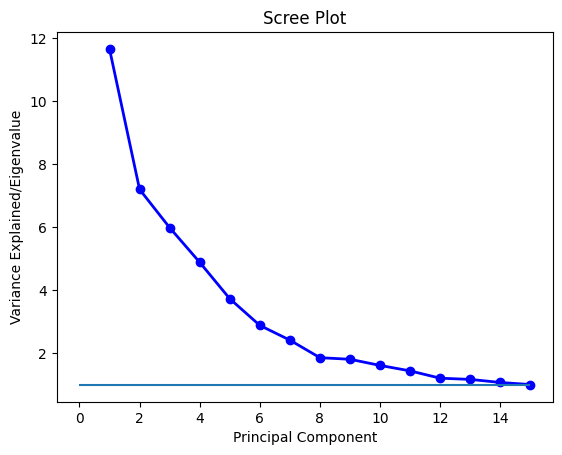

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.711407  0.100296 -0.307041  0.315571  0.139732   
constructive_feedback -0.179394  0.529845 -0.204930 -0.086249  0.114949   
author_revelation     -0.598407  0.117177 -0.083558 -0.231168  0.214520   
comprehensibility      0.318199  0.100969 -0.499996 -0.468995 -0.008404   
detail_level           0.419114 -0.223676 -0.489900  0.386348  0.060758   
...                         ...       ...       ...       ...       ...   
context-first         -0.082569 -0.152123 -0.267955  0.506942 -0.054117   
setting-first          0.013382 -0.269425 -0.327686  0.386342 -0.079487   
chronological          0.014576 -0.368768 -0.455947  0.318923 -0.039933   
transition_level      -0.085346 -0.153729 -0.415946  0.450595  0.019510   
causal_level          -0.104125  0.117126 -0.224740  0.355821  0.326581   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=11, rotation='varimax')
X_fa = fa.fit_transform(X_norm)

rotated_loadings = fa.components_.T


print(fa.components_)

rotated_pca_df = pd.DataFrame(data=rotated_loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(rotated_pca_df)
rotated_pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/news_rotated_pca_analysis.xlsx')

# pca_df = pd.DataFrame(data=rotated_loadings,
#                       columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
#                       index=X.columns)
# print(pca_df)
# pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/pca_analysis.xlsx')

[[-8.16525816e-02 -1.20475849e-01 -3.39089778e-02 -7.09000212e-03
   2.21213696e-01 -3.30220465e-02  6.02423360e-02 -2.55029445e-01
  -9.44000359e-02  3.99024558e-01 -2.81566686e-02 -4.32008354e-03
  -1.32244009e-01 -2.87137146e-02  9.18816991e-02  2.92574843e-02
   1.04712324e-02  1.49950872e-02  3.95462908e-02 -5.59547907e-03
  -2.61120459e-02  3.82810129e-03  1.35330913e-03  4.58368176e-03
   4.28763864e-02  3.29569923e-02  8.32791600e-02  1.00310346e-01
  -1.13598701e-02 -3.39152487e-02 -2.37819469e-02 -6.29864878e-02
  -1.06573328e-01 -5.56512554e-02  2.81061030e-01  3.23305092e-01
   2.35649267e-01 -1.26386677e-01 -2.24433200e-02 -1.48910504e-01
  -9.56168586e-03  1.77946502e-01 -2.33578809e-02 -1.24504928e-01
   1.23565123e-01  1.64632650e-01 -1.78474969e-01 -4.86840917e-02
  -4.22828635e-02 -1.84247951e-02  3.32932850e-02 -7.52580335e-02
   9.68934303e-01  9.69304713e-01 -1.75605015e-01  9.21888868e-01
   1.44793623e-02  3.91140873e-01 -5.43025089e-02  1.61558052e-02
   3.03085

In [ ]:
PC_values = np.arange(fa.components_) + 1
plt.plot(PC_values, fa.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(fa.explained_variance_))
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.711407
author_revelation,-0.598407
explicitness,0.604542
implied_meaning,-0.711808
creative_text,-0.663621
vividness,-0.578070
expressfulness,-0.748888
matter_of_factness,0.882314
abstractness,-0.510118
figurativeness,-0.623831


In [ ]:
rotated_pc1_df = rotated_pca_df[['PC1']]
rotated_pc1_df = rotated_pc1_df[(rotated_pc1_df['PC1'] <= -0.5) | (rotated_pc1_df['PC1'] >= 0.5)]
rotated_pc1_df

,PC1
narrative,0.968934
narrative_mode,0.969305
storytelling,0.921889


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
constructive_feedback,0.529845
persuasiveness,0.611041
supportiveness,0.628072
conflict,0.557044
vividness,-0.504759
narrative,-0.586009
narrative_mode,-0.584921
storytelling,-0.574043
prosociality,0.650433
showing,-0.515938


In [ ]:
rotated_pc2_df = rotated_pca_df[['PC2']]
rotated_pc2_df = rotated_pc2_df[(rotated_pc2_df['PC2'] <= -0.5) | (rotated_pc2_df['PC2'] >= 0.5)]
rotated_pc2_df

,PC2
informativeness,-0.775832
detail_level,-0.651488
formality,-0.540356
exposition,-0.948686
expository_mode,-0.911631


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
explicitness,-0.508588
vagueness,0.572135
narrative,-0.507220
narrative_mode,-0.505603
clarity,-0.563274


In [ ]:
rotated_pc3_df = rotated_pca_df[['PC3']]
rotated_pc3_df = rotated_pc3_df[(rotated_pc3_df['PC3'] <= -0.5) | (rotated_pc3_df['PC3'] >= 0.5)]
rotated_pc3_df

,PC3
comprehensibility,-0.888722
explicitness,-0.666623
context_dependence,0.509866
vagueness,0.551903
conciseness,-0.596914
directness,-0.649609
indirect,0.529815
clarity,-0.918216


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
formality,0.506388
conciseness,-0.574993
verbosity,0.585458
context-first,0.506942


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
right_wrong,0.647600
point_faults,-0.559449
tactful,-0.683263
challenge,0.586094
politeness,-0.569452
bluntness,0.695682


In [ ]:
pc6_df = pca_df[['PC6']]
pc6_df = pc6_df[(pc6_df['PC6'] <= -0.5) | (pc6_df['PC6'] >= 0.5)]
pc6_df

,PC6
self-reliance,0.519409


In [ ]:
pc7_df = pca_df[['PC7']]
pc7_df = pc7_df[(pc7_df['PC7'] <= -0.3) | (pc7_df['PC7'] >= 0.3)]
pc7_df

,PC7
context_dependence,-0.424767
creative_text,0.495368
vividness,0.377469
expressfulness,0.347727
figurativeness,0.539038
narrative,-0.308479
narrative_mode,-0.304000
storytelling,-0.311344


In [ ]:
pc8_df = pca_df[['PC8']]
pc8_df = pc8_df[(pc8_df['PC8'] <= -0.3) | (pc8_df['PC8'] >= 0.3)]
pc8_df

,PC8
comprehensibility,0.360061
accomplish_tasks,-0.368378
critique,0.427149
conciseness,0.395685
context-first,0.416822
setting-first,0.340554


In [ ]:
pc9_df = pca_df[['PC9']]
pc9_df = pc9_df[(pc9_df['PC9'] <= -0.3) | (pc9_df['PC9'] >= 0.3)]
pc9_df

,PC9
author_revelation,0.343336
anecdotal_reasoning,0.443707
status_suggestion,-0.347232
status_appropriateness,-0.351805
build_connection,0.460092
suspensefulness,-0.311768


In [ ]:
pc10_df = pca_df[['PC10']]
pc10_df = pc10_df[(pc10_df['PC10'] <= -0.3) | (pc10_df['PC10'] >= 0.3)]
pc10_df

In [ ]:
pc11_df = pca_df[['PC11']]
pc11_df = pc11_df[(pc11_df['PC11'] <= -0.2) | (pc11_df['PC11'] >= 0.2)]
pc11_df

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_norm)

print(f"t-SNE reduced data shape: {X_tsne.shape}")

# 6. Visualization of t-SNE results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y, cmap='viridis', alpha=0.8)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Style Features')
# target_names = ['Very Low-Context', 'Low-Context', 'High-Context', 'Very High-Context']
target_names = ['Low-Context', 'High-Context']
plt.colorbar(scatter, ticks=range(len(target_names)), label='Context-Level')
plt.clim(-0.5, len(target_names) - 0.5) # Adjust colorbar limits to center ticks
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=)
fig.update_layout(
    title="PCA visualization of Customer Churn dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig.show()

In [ ]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size=0.2, random_state=7)

# Correlation Analysis (Chinese)

In [ ]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
## Loading Chinese feature tables
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_news_metadiscourseFeatures.csv"
chinese_styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_news_styleFeatures.csv"

chinese_df_metadiscourse = pd.read_csv(chinese_metadiscourseFeature_Table_path, index_col=0)
chinese_df_style = pd.read_csv(chinese_styleFeature_Table_path, index_col=0)

In [ ]:
chinese_df_metadiscourse.rename(columns={'utterance_id': 'message_id'}, inplace=True)

chinese_metadiscourseStyleFeatures_df = pd.merge(chinese_df_metadiscourse, chinese_df_style, on='message_id', how='inner')

In [ ]:
print(chinese_metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
place_time_svo           float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 111, dtype: object


In [ ]:
## Computing correlations for chinese_dataset
X = chinese_metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,place_time_svo,transitions,chronological_markers,adverbs_of_degree,causal_markers,deontic_modal_words,explicit_references,evidentials,frame_markers,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,-0.084275,0.072348,-0.022256,-0.019739,0.046889,0.052469,-0.010282,-0.012128,0.000006,...,0.129853,-0.014309,-0.460528,0.191610,0.130336,0.094704,-0.002646,-0.056122,0.027744,-0.038609
place_time_svo,-0.084275,1.000000,-0.055281,0.011100,-0.012713,-0.071869,-0.069137,0.102372,-0.032780,-0.052390,...,-0.027769,-0.092555,0.140901,-0.090508,-0.031033,0.175396,0.355417,0.164907,0.024177,-0.116700
transitions,0.072348,-0.055281,1.000000,-0.049541,-0.004545,-0.103197,0.022419,-0.086283,-0.031715,-0.066047,...,0.038607,0.015246,-0.063430,0.030600,-0.011711,0.001619,-0.061780,-0.003551,0.185337,-0.029458
chronological_markers,-0.022256,0.011100,-0.049541,1.000000,-0.072986,0.014885,-0.062443,-0.033972,-0.012297,0.009221,...,0.051220,-0.057324,0.035177,-0.023821,0.029203,0.121837,0.157473,0.427794,0.276624,0.029083
adverbs_of_degree,-0.019739,-0.012713,-0.004545,-0.072986,1.000000,0.063057,0.012033,-0.005084,-0.021274,-0.016416,...,-0.011841,-0.013042,0.016063,0.029823,-0.009674,-0.087812,-0.078986,-0.075572,-0.063000,0.001046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.094704,0.175396,0.001619,0.121837,-0.087812,-0.001526,-0.128078,-0.036486,0.093162,-0.025053,...,0.055386,0.038908,-0.117029,0.183572,0.245732,1.000000,0.744479,0.348595,0.424102,0.187895
setting-first,-0.002646,0.355417,-0.061780,0.157473,-0.078986,-0.081616,-0.131333,0.046070,0.045884,-0.043872,...,0.066584,-0.057086,0.025418,0.127535,0.263096,0.744479,1.000000,0.425002,0.356893,0.032027
chronological,-0.056122,0.164907,-0.003551,0.427794,-0.075572,-0.005969,-0.141476,-0.030405,-0.035241,0.035131,...,0.166747,-0.064342,0.076483,0.176444,0.293268,0.348595,0.425002,1.000000,0.665114,0.168632
transition_level,0.027744,0.024177,0.185337,0.276624,-0.063000,0.128167,-0.135158,-0.140852,-0.048378,0.022523,...,0.153986,0.055849,-0.050937,0.273077,0.271465,0.424102,0.356893,0.665114,1.000000,0.404621


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_high_context_df = corr[['avg_labeled_utterance']]
chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
chinese_high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_context_correlation.xlsx")
print(chinese_high_context_df)

                       avg_labeled_utterance
clarity                            -0.460528
matter_of_factness                 -0.387269
explicitness                       -0.377653
informativeness                    -0.366552
comprehensibility                  -0.356387
...                                      ...
vagueness                           0.364134
indirect                            0.381122
implied_meaning                     0.405939
context_dependence                  0.439664
avg_labeled_utterance               1.000000

[107 rows x 1 columns]


/tmp/ipython-input-49817410.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_feature_correlation.csv", index_col = 0)

# Create a copy to modify
chinese_filtered_corr_matrix = chinese_corr.copy()

thresh = 0.65

chinese_corr_pairs = chinese_filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
chinese_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
chinese_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Feature_1'] != chinese_corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
chinese_corr_pairs['Ordered_Pair'] = chinese_corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
chinese_corr_pairs = chinese_corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
chinese_corr_pairs['Feature_1_Context_Corr'] = chinese_corr_pairs['Feature_1'].map(chinese_high_context_df['avg_labeled_utterance'])
chinese_corr_pairs['Feature_2_Context_Corr'] = chinese_corr_pairs['Feature_2'].map(chinese_high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
chinese_corr_pairs['Lower_Context_Feature'] = chinese_corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
chinese_most_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Correlation'] >= thresh]
chinese_most_corr_pairs = chinese_most_corr_pairs.sort_values(by='Correlation', ascending=False)
chinese_most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## Chinese - Correlation Clustering/PCA

In [ ]:
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_chinese_testing_context_input.csv')
X = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_output_testing_styleFeatures.csv')
X = X.drop(['Unnamed: 0', 'message_id', 'orientation'], axis=1)

Y = chinese_labeled_context_input_df[['avg_labeled_utterance']]
# Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 2 else 1 if 2 <= x < 3 else 2 if 3 <= x < 4 else 3)
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: avg_labeled_utterance, Length: 1000, dtype: int64


In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=14)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.43% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[11.11008537  7.88872793  6.25719508  4.40960893  3.33481139  2.72293388
  2.12934564  1.99333344  1.74625086  1.62721848  1.36465827  1.25965501
  1.14229492  1.02287008]
[0.16565635 0.11762447 0.09329758 0.06574924 0.04972353 0.04060016
 0.0317495  0.02972149 0.02603738 0.02426256 0.02034767 0.01878202
 0.01703213 0.01525145]


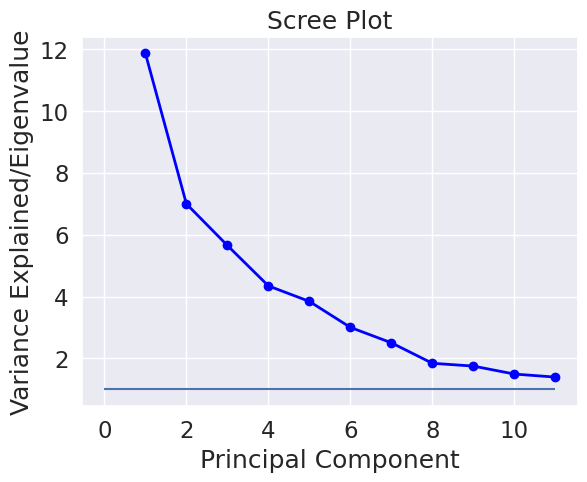

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run UM/chinese_news_pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.655046  0.255138  0.442985 -0.144504  0.051636   
constructive_feedback -0.257948  0.512059  0.062725  0.213861  0.125353   
author_revelation     -0.581917  0.107875 -0.099103  0.239319  0.250111   
comprehensibility      0.283994  0.097117  0.154364  0.589130 -0.057456   
detail_level           0.352763 -0.055592  0.652584 -0.151259  0.047320   
...                         ...       ...       ...       ...       ...   
context-first         -0.166438 -0.076298  0.411497 -0.333431 -0.079661   
setting-first         -0.031842 -0.232875  0.433447 -0.192147 -0.145408   
chronological         -0.038163 -0.297987  0.588462 -0.048788 -0.055707   
transition_level      -0.205610 -0.077432  0.572865 -0.219716  0.001852   
causal_level          -0.165885  0.231228  0.355067 -0.246608  0.251496   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
informativeness,0.655046
author_revelation,-0.581917
explicitness,0.571543
empathy,-0.508870
implied_meaning,-0.695979
creative_text,-0.586561
vividness,-0.560786
expressfulness,-0.757608
matter_of_factness,0.861830
figurativeness,-0.555909


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
constructive_feedback,0.512059
persuasiveness,0.592332
supportiveness,0.562221
group_wellbeing,0.525859
vividness,-0.511766
narrative,-0.567537
narrative_mode,-0.570315
storytelling,-0.551549
prosociality,0.637041


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
detail_level,0.652584
narrative,0.558000
narrative_mode,0.552424
storytelling,0.510941
chronological,0.588462
transition_level,0.572865


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
comprehensibility,0.589130
clarity,0.578018


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
right_wrong,0.681049
point_faults,-0.598400
tactful,-0.721705
challenge,0.578069
politeness,-0.622270
bluntness,0.744876


# Human evaluation

In [ ]:
## Loading feature tables

## using non-normalized metadiscourse feature table for human evaluation - so that it is to count and verify correctness of LLM annotations
metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/output_metadiscourseFeatures_notNormalized.csv"
styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/output_styleFeatures.csv"

df_metadiscourse = pd.read_csv(metadiscourseFeature_Table_path, index_col=0)
df_style = pd.read_csv(styleFeature_Table_path, index_col=0)

In [ ]:
metadiscourseStyleFeatures_df = pd.merge(df_metadiscourse, df_style, on='message_id', how='inner')

In [ ]:
metadiscourseStyleFeatures_df.head()

In [ ]:
# set the number of samples for human evaluation
k =20
random_sample = metadiscourseStyleFeatures_df.sample(n=k, random_state=42)

In [ ]:
#set output file path to save output
human_evaluation_english_path = "/content/drive/MyDrive/High and Low Context Files/Code/human_evaluation_english.csv"
random_sample.to_csv(human_evaluation_english_path)

# DLATK analysis

#ARCHIVED PROMPTS

In [ ]:
##### JAPANESE POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/indexed_japanese_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_japanese_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=2500)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
df_output_context_2 = pd.DataFrame(output_contextLabels_2)
df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
print(df_output_context)

##saving output_context table
print("Saving new labeled context input table")
df_output_context.to_csv(output_context_filepath)

print("Finished")

In [ ]:
##### SPANISH POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/indexed_spanish_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_spanish_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=2500)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
df_output_context_2 = pd.DataFrame(output_contextLabels_2)
df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
print(df_output_context)

##saving output_context table
print("Saving new labeled context input table")
df_output_context.to_csv(output_context_filepath)

print("Finished")

In [ ]:
##### JAPANESE METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_japanese_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/japanese_output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/japanese_output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=2500)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

In [ ]:
##### SPANISH METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_spanish_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/spanish_output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/spanish_output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=2500)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

In [ ]:
#####  EXTRACTING JAPANESE STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_japanese_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/japanese_output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.head(n=2500)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


In [ ]:
#####  EXTRACTING SPANISH STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_spanish_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/spanish_output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.head(n=2500)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


In [ ]:
#####  TRANSLATING JAPANESE UTTERANCES #####

## Input - Labeled Japanese Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_japanese_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/translated_japanese_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=10)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")

In [ ]:
#####  TRANSLATING SPANISH UTTERANCES #####

## Input - Labeled Spanish Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/labeled_spanish_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run UM/translated_spanish_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=10)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")

In [ ]:
## Run 1 for metadiscourse feature labeling (pre-addition of storytelling features and pre-removal of high correlates)
def extract_metadiscourseFeatures_english(post, temp):
  response = openai.chat.completions.create(
  model="chatgpt-4o-latest",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in two to three sentence-long utterances."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in two to three sentence-long utterances are.",
       "description": "Identify and label metadiscourse markers in the given text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>. DO NOT EXPLAIN YOUR ANSWERS",
  "categories": {{
    "interactive": {{
      "": {{
        "definition": "Words that express semantic relation between main clauses.",
        "examples": ["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"]
      }},
      "frame_markers": {{
        "definition": "Words that refer to discourse acts, sequences, or text stages.",
        "examples": ["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"]
      }},
      "endophoric_markers": {{
        "definition": "Words that refer to information from other parts of the text.",
        "examples": ["what I mentioned before", "the above", "above", "below", "first"]
      }},
      "evidentials": {{
        "definition": "Words that refer to a source of information from other texts.",
        "examples": ["as xxx once said", "according to xxx"]
      }},
      "code_glosses": {{
        "definition": "Words that help readers grasp meanings of ideational material.",
        "examples": ["such as", "for example", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "Words that withhold the writer's full commitment to a proposition.",
        "examples": ["might", "could", "I'm not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"]
      }},
      "boosters": {{
        "definition": "Words that emphasize force or the writer's certainty in a proposition.",
        "examples": ["definitely", "certainly", "really", "in fact", "exclamation marks (!)", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"]
      }},
      "attitude_markers": {{
        "definition": "Words that express the writer's attitude to a proposition.",
        "examples": ["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"]
      }},
      "engagement_markers": {{
        "definition": "Words that explicitly refer to or build a relationship with the reader.",
        "examples": ["consider this", "you can see that", "have to", "question marks (?)", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"]
      }},
      "self_mentions": {{
        "definition": "Words that indicate explicit reference to the author(s).",
        "examples": ["I", "we", "our", "me", "us", "my"]
      }}
    }},
    "other": {{
      "deontic_modal_words": {{
        "definition": "Words or word phrases that express concepts of obligation, permission, and prohibition, often in the context of what a person or agent is required, allowed, or forbidden to do.",
        "examples": ["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to"]
      }},
      "adverbs_of_degree": {{
        "definition": "Words that indicate the intensity, extent, or level of an action, adjective, or another adverb",
        "examples": ["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too"]
      }},
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "slang_and_colloquialisms": {{
        "definition": "Words or phrases commonly used in natural, highly informal, spoken conversations rather than in formal or literary writing, including ones popular in specific social groups.",
        "examples": ["going postal", "bogus", "adulting", "y'all", "what's up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin". "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow-up", "GOAT", "let them cook", "irl", "mood"]
      }},
      "positive_connotations": {{
        "definition": "Words with emotional or cultural associations that goes beyond their literal meanings, with positive connotations evoke pleasant or favorable feelings and associations.",
        "examples": ["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent"]
      }},
      "negative_connotations": {{
        "definition": "Words with unpleasant or unfavorable emotional associations or implied meanings, beyond their literal definitiona.",
        "examples": ["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "Some guy tried to do the same thing with me<self-mentions> once!<boosters> He faked cancer for about a month, then<transitions> one day, he “had a heart attack,”<boosters> and told me<self-mentions> the hospital he was admitted into. I<self-mentions> called the hospital, and they had no record of him there. So I<self-mentions> aggressively confronted the guy, he admitted he was lying about everything, and I<self-mentions> told him he needed professional mental help. People who are THIS<boosters> crazy are scary… they don’t know what’s right vs wrong."
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  temperature=temp,
  max_tokens=1024,
  # gpt-5 only params: reasoning_effort
  # reasoning_effort="medium",
  # verbosity="low",
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

In [ ]:
## Run 1 for STYLE feature labeling (pre-addition of storytelling features and pre-removal of high correlates)
def extract_styleFeatures_english(post, temp):
    response = openai.chat.completions.create(
        model="chatgpt-4o-latest",
        messages=[
            {
                "role": "system",
                "content": "You are an AI assistant trained to evaluate and annotate advice given in social media posts based on various criteria. Rate each question on a scale from 1 (not at all) to 7 (very much), unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Annotate advice-related social media posts based on multiple linguistic and psychological dimensions.",
                    "description": "Rate each of the following questions on a scale of 1 (not at all) to 7 (very much). Select temporal orientation as past, present, or future. If multiple orientations apply, return all that apply.\
                    ALWAYS FOLLOW THE RATING SCALE OF 1 (not at all) TO 7 (very much) EXCEPT FOR TEMPORAL ORIENTATION. DO NOT EXPLAIN YOUR ANSWERS.\
                    ",
                    "criteria": {{
                        "informativeness": "How much does this advice provide information or solutions?",
                        "constructive_feedback": "How much does this advice offer constructive feedback?",
                        "criticality": "How much does this advice criticise?",
                        "self_disclosure": "How much self-disclosure is there in this advice?",
                        "author_revelation": "How much does this advice reveal about the author?",
                        "comprehensibility": "How easy is this advice to understand?",
                        "detail_level": "How detailed is this advice?",
                        "explicitness": "How explicit is this advice?",
                        "context_dependence": "How much additional context is needed to understand this advice?",
                        "persuasiveness": "How much does this advice attempt to persuade the reader of a point?",
                        "logical_reasoning": "How much does this advice emphasize logical reasoning?",
                        "anecdotal_reasoning": "How much does this advice rely on anecdotal or experiential reasoning?",
                        "right_wrong": "How much does this advice frame actions in terms of right and wrong?",
                        "tradition": "How much does this advice appeal to tradition or authority?",
                        "supportiveness": "How supportive is this advice?",
                        "empathy": "How empathetic is this advice?",
                        "status_suggestion": "How much does this advice suggest that the people are of different status?",
                        "status_appropriateness": "How appropriate is the advice for their status difference?",
                        "personal_choice": "How much does this advice emphasize personal choice?",
                        "independence": "How much does this advice emphasize independence?",
                        "group_harmony": "How much does this advice emphasize group harmony?",
                        "shared_responsibility": "How much does this advice emphasize shared responsibility?",
                        "self-reliance": "How much does this advice emphasize self-reliance?",
                        "cooperation": "How much does this advice promote cooperation?",
                        "group_wellbeing": "How much does this advice focus on group well-being?",
                        "self_growth": "How much does this advice emphasize self-growth?",
                        "self_responsibility": "How much does this advice place responsibility on the individual?",
                        "ext_responsibility": "How much does this advice place responsibility on external factors or others?",
                        "other_reliance": "How much does this advice emphasize relying on others?",
                        "maintain_relationship": "How much does this advice prioritize maintaining relationships?",
                        "accomplish_tasks": "How much does this advice prioritize accomplishing tasks?",
                        "implied_meaning": "How much does this advice imply meaning rather than state it?",
                        "creative_text": "How much does this advice use metaphors, analogies, or storytelling to convey its message?",
                        "repetitive": "How much does this advice repeat key ideas or phrases to enhance clarity?",
                        "point_faults": "How much does this advice avoid naming problems or pointing out faults directly?",
                        "tactful": "How tactful is this advice?",
                        "critique": "How much does this advice soften critique through indirect or roundabout language?",
                        "challenge": "How openly does this advice challenge assumptions, behaviors, or norms?",
                        "conflict": "How much does this advice downplay disagreement or conflict to maintain social harmony?",
                        "build_connection": "How much does this advice include personal anecdotes or experiences to build connection?",
                        "relational_1":"How much does this advice prioritize maintaining relationships?",
                        "orientation": "Which time period does this advice most focus on?",
                        "vividness": "How vivid is this utterance?",
                        "expressfulness": "How expressful is this utterance?",
                        "vagueness": "How vague is this utterance?",
                        "matter_of_factness": "How matter-of-fact is this utterance?",
                        "abstractness": "How abstract is this utterance?",
                        "figurativeness": "How figurative is this utterance?",
                        "concreteness": "How concrete is this utterance?",
                        "formality": "How formal is this utterance?",
                        "conciseness": "How concise is this utterance?",
                        "verbosity": "How verbose is this utterance?",
                        "emotionality": "How emotional is this utterance?",
                        "impersonality": "How impersonal is this utterance?",
                        "politeness": "How polite is this utterance?",
                        "directness": "How direct is this utterance?",
                        "bluntness": "How blunt is this utterance?",
                        "cultural-relatedness": "How much cultural knowledge does this utterance use?"
                    }},
                    "rating_scale": "For all questions (except temporal orientation), rate on a scale of 1 (not at all) to 7(very much or a lot)."
                }},
                "text": "{post}"
               }}
                '''
            }
        ],
        temperature=temp,
        max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output